# 📦 Import Libraries



In [26]:
# ── Standard Libraries ──────────────────────────────
import numpy as np
import pandas as pd
import re
from collections import Counter

# ── Visualization ────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
import seaborn as sns
from wordcloud import WordCloud

# ── Arabic NLP ───────────────────────────────────────
import arabic_reshaper
from bidi.algorithm import get_display
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# ── Scikit-learn ─────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import class_weight

# ── TensorFlow / Keras ───────────────────────────────
import tensorflow as tf
from tensorflow.keras import backend as K, regularizers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import (
    Input, Embedding, SpatialDropout1D,
    Bidirectional, LSTM, BatchNormalization,
    Dense, Dropout
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gemar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# 📂 Load Data


In [27]:
df = pd.read_csv("../data/dataset.csv")

print(f"إجمالي عدد التغريدات: {len(df)}")
df.head()

إجمالي عدد التغريدات: 40046


,Unnamed: 0,review_description,rating,company
0,0,رائع,1,talbat
1,1,برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...,1,talbat
2,2,التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...,-1,talbat
3,3,لماذا لا يمكننا طلب من ماكدونالدز؟,-1,talbat
4,4,البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...,-1,talbat


# 🧹 Data Cleaning & Preprocessing

In [28]:
df = df[['review_description', 'rating']].dropna()
df = df[df['rating'].isin([1, 0, -1])]
df['label'] = df['rating'].map({1: 'pos', 0: 'neu', -1: 'neg'})

In [29]:
# Oversample neutral class only
neu_df = df[df['label'] == 'neu']
extra_neu = pd.concat([neu_df] * 9)  # أضف 9 نسخ إضافية = x10 للـ neu فقط

df = pd.concat([df, extra_neu]).reset_index(drop=True)

# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df['label'].value_counts())
print(f"Total reviews: {len(df)}")

label
pos    23921
neu    19250
neg    14199
Name: count, dtype: int64
Total reviews: 57370


## 🔍 Check & Remove Duplicates / Nulls


In [30]:
# Check nulls and duplicates
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Clean
df = df[['review_description', 'label']].dropna()
df = df.drop_duplicates()
df = df.reset_index(drop=True)
print(f"Total rows after cleaning: {len(df)}")

review_description    0
rating                0
label                 0
dtype: int64
Duplicates: 18266
Total rows after cleaning: 39104


## ⚖️ Balance Classes (Oversample Neutral)

In [31]:
# Oversample neutral class only
neu_df = df[df['label'] == 'neu']
extra_neu = pd.concat([neu_df] * 9)
df = pd.concat([df, extra_neu]).reset_index(drop=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df['label'].value_counts())
print(f"Total reviews: {len(df)}")

label
pos    23211
neu    19180
neg    13975
Name: count, dtype: int64
Total reviews: 56366


In [32]:
df.info()
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print(f"Columns names: {df.columns.tolist()}")
print(f"Data types:\n{df.dtypes}")
print(df['label'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56366 entries, 0 to 56365
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  56366 non-null  object
 1   label               56366 non-null  object
dtypes: object(2)
memory usage: 880.8+ KB
Rows    : 56366
Columns : 2
Columns names: ['review_description', 'label']
Data types:
review_description    object
label                 object
dtype: object
label
pos    23211
neu    19180
neg    13975
Name: count, dtype: int64


## 📏 Text Length Analysis


In [33]:
df['text_length'] = df['review_description'].apply(len)

# Stats
print(f"Max length : {df['text_length'].max()} chars")
print(f"Min length : {df['text_length'].min()} chars")
print(f"Avg length : {df['text_length'].mean():.1f} chars")

# Longest text
longest_text = df.loc[df['text_length'].idxmax(), 'review_description']
print(f"\nLongest review:\n{longest_text}")

# Top 5 longest
top5 = df.nlargest(5, 'text_length')[['review_description', 'text_length']].reset_index(drop=True)
for i, row in top5.iterrows():
    print(f"{'='*60}")
    print(f"Rank {i+1} | {row['text_length']} chars")
    print(f"{row['review_description']}")
print('='*60)

Max length : 2481 chars
Min length : 1 chars
Avg length : 54.9 chars

Longest review:
الي/ السيد الاستاذ رئيس مجلس إدارة شركة طلعت مصطفي

تحية طيبه وبعد

فوجئت عند عودتي من خارج البلاد يوم ١١ مايو ٢٠١٨ بسرقة شقتي الواقعة بمجموعه ٩٩ عمارة ١٠ شقة ٥١. تمت سرقة الشقة بواسطة مجرم استطاع فتح باب الشقة بدون كسر الباب وسرق تليفزيون ٤٢ بوصة وميكروويف وقام بكسر الخزانة من الخلف بواسطة آدآه حادة.

استطاع السارق ان يسرق التليفزيون والميكرويف ويخرج بهم من العمارة دون ان يمنعه رجال الأمن او يلاحظوة. وفوجئت بأن شقة اخري سرقت بنفس الطريقه في ١٧ ابريل ٢٠١٨ وهي شقه ٥٥ الموجودة بنفس الطابق الذي اسكن به ومملوكة لمهندسة تعمل بشركة وتتواجد بشقتها يوميا بعد ساعات العمل. وأيضا تم فتح باب شقتها بدون كسر اثنآء تواجدها خارج المنزل.
كيف يمكن ان يستطيع أي شخص ان يخرج بتليفزيون وميكروويف من العمارة بدون ان يستوقفة رجال الأمن؟ وكيف يمكن ان يراقب السكان بهذة الطريقه.

هل وصل التقصير الي هذا الحد؟ ام هو فساد منظومة الأمن بمدرآئها وأفرادها واجهزتها. عندما طلبت من مدير الأمن سيد ابوالخيرسجل الزيارات التي وصلت الي شقتي ا

## 📊 Label Distribution Plot


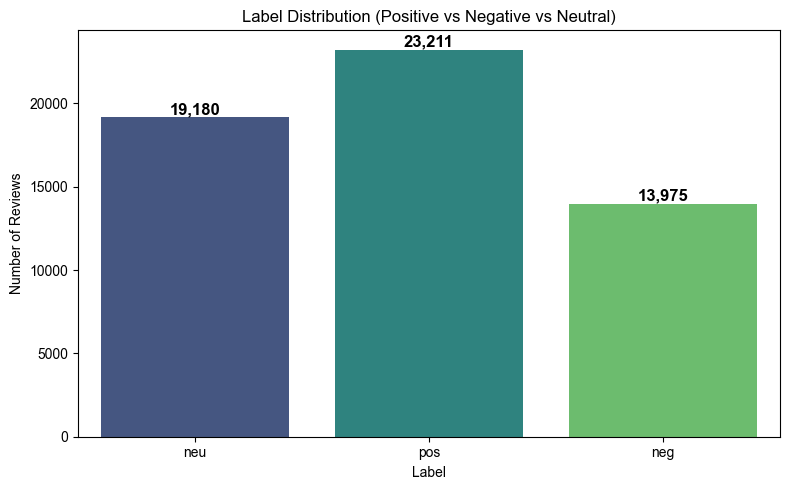

In [34]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='label', data=df, hue='label', palette='viridis', legend=False)

# إضافة الأرقام فوق كل عمود
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Label Distribution (Positive vs Negative vs Neutral)')
plt.xlabel('Label')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## 🧼 Arabic Text Cleaning


In [35]:
def clean_arabic_text(text):
    text = re.sub(r"http\S+|www\S+|@\S+|#", "", text)       # Remove links/mentions
    text = re.sub(r"[\u064B-\u0652]", "", text)               # Remove tashkeel
    text = re.sub("[إأآا]", "ا", text)                        # Normalize alef
    text = re.sub("ى", "ي", text)                             # Normalize ya
    text = re.sub("ة", "ه", text)                             # Normalize ta marbuta
    text = re.sub("ؤ", "ء", text)                             # Normalize waw hamza
    text = re.sub("ئ", "ء", text)                             # Normalize ya hamza
    text = re.sub(r"[^\u0621-\u064A\s]", " ", text)           # Keep Arabic only
    text = re.sub(r"\s+", " ", text).strip()                  # Remove extra spaces
    return text

df['clean_text'] = df['review_description'].apply(clean_arabic_text)

## ☁️ Word Cloud


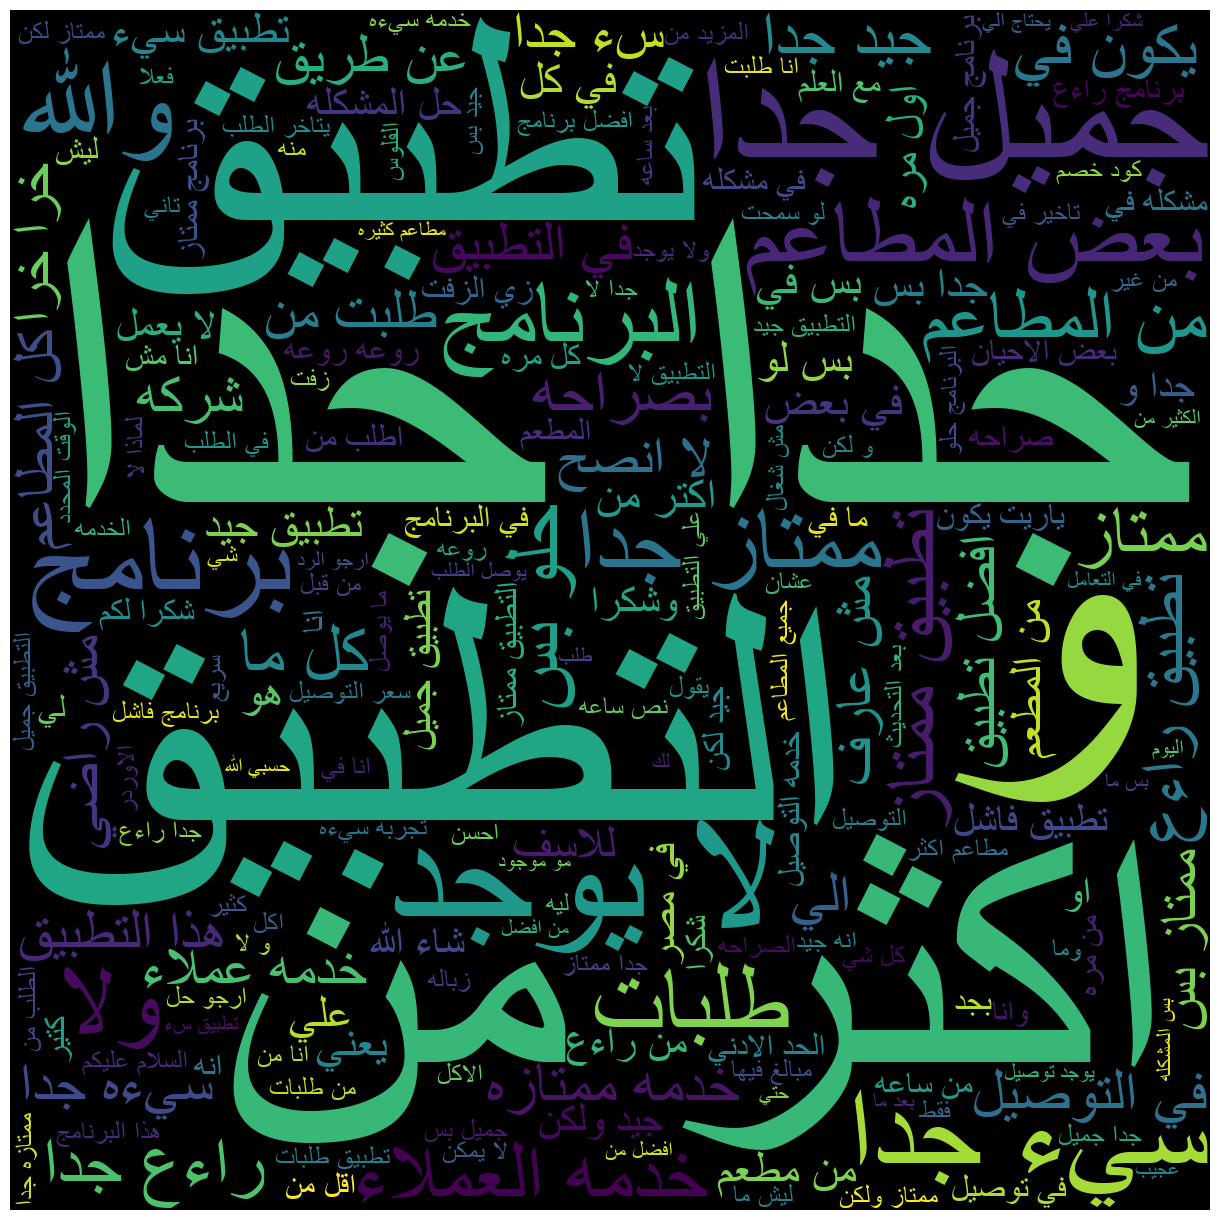

In [36]:
text = ' '.join(df['clean_text'])
reshaped_text = arabic_reshaper.reshape(text)
bidi_text = get_display(reshaped_text)

wordcloud = WordCloud(
    width=1200, height=1200,
    background_color='black',
    font_path='arial.ttf',
    min_font_size=10
).generate(bidi_text)

plt.figure(figsize=(12, 12))
plt.imshow(wordcloud)
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

## 🚫 Remove Stopwords

In [37]:
arabic_stopwords = set(stopwords.words('arabic'))

# Keep negation words — important for sentiment
negative_words = {'لا', 'ما', 'لم', 'ليس', 'لن', 'غير', 'بدون', 'لو', 'مو'}
arabic_stopwords -= negative_words

# Add extra stopwords
extra_words = {'تم', 'ان', 'كان', 'يكون', 'عن', 'بعد', 'قبل'}
arabic_stopwords.update(extra_words)

def remove_stopwords(text):
    words = text.split()
    return ' '.join([w for w in words if w not in arabic_stopwords])

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
print(f"Total stopwords used: {len(arabic_stopwords)}")

Total stopwords used: 697


## 🔢 Tokenization & Padding


In [38]:
MAX_VOCAB = 60000
MAX_LEN   = 150

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])
X_padded  = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Matrix shape: {X_padded.shape}")

Matrix shape: (56366, 150)


## 🏷️ Label Encoding


In [39]:
le = LabelEncoder()
y  = le.fit_transform(df['label'])

print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(df['label'].value_counts())

Classes: {'neg': np.int64(0), 'neu': np.int64(1), 'pos': np.int64(2)}
label
pos    23211
neu    19180
neg    13975
Name: count, dtype: int64


## ✂️ Train / Validation / Test Split

In [40]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_padded, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

Train: 39456 | Val: 8455 | Test: 8455


## 🧠 Self-Attention Layer


In [41]:
class SelfAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(input_shape[1], 1),
                                 initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, x):
        e      = tf.tanh(tf.matmul(x, self.W) + self.b)
        a      = tf.nn.softmax(e, axis=1)
        output = tf.reduce_sum(x * a, axis=1)
        return output

## 🏗️ Model Architecture (BiLSTM + Attention)


In [42]:
inputs = Input(shape=(MAX_LEN,))
x = Embedding(input_dim=MAX_VOCAB, output_dim=128)(inputs)
x = SpatialDropout1D(0.3)(x)
x = Bidirectional(LSTM(64, return_sequences=True, recurrent_dropout=0.4,
                       kernel_regularizer=regularizers.l2(0.01)))(x)
x = SelfAttention()(x)
x = BatchNormalization()(x)
x = Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
x = Dropout(0.4)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding (Embedding)                │ (None, 150, 128)            │       7,680,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d (SpatialDropout1D) │ (None, 150, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 150, 128)            │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ self_attention (SelfAttention)       │ (None, 128)                 │             278 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,783,833 (29.69 MB)

 Trainable params: 7,783,577 (29.69 MB)

 Non-trainable params: 256 (1.00 KB)

## ⚖️ Class Weights


In [43]:
class_weights_arr = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights_dict = {
    0: 1.0,   # neg
    1: 6.0,   # neu — عاقبه أكثر على الأخطاء
    2: 1.0    # pos
}
print("Class weights:", weights_dict)

Class weights: {0: 1.0, 1: 6.0, 2: 1.0}


## 🏋️ Model Training


In [44]:
early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                               patience=2, min_lr=1e-6, verbose=1)

history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=weights_dict,
    shuffle=True,
    verbose=1
)

Epoch 1/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 112s 176ms/step - accuracy: 0.3441 - loss: 3.3041 - val_accuracy: 0.3412 - val_loss: 1.7222 - learning_rate: 5.0000e-04
Epoch 2/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 102s 165ms/step - accuracy: 0.5537 - loss: 1.7360 - val_accuracy: 0.6811 - val_loss: 1.0591 - learning_rate: 5.0000e-04
Epoch 3/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 102s 165ms/step - accuracy: 0.7452 - loss: 1.0935 - val_accuracy: 0.8358 - val_loss: 0.6292 - learning_rate: 5.0000e-04
Epoch 4/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 103s 167ms/step - accuracy: 0.8112 - loss: 0.8117 - val_accuracy: 0.7890 - val_loss: 0.6332 - learning_rate: 5.0000e-04
Epoch 5/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.8420 - loss: 0.6829
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
617/617 ━━━━━━━━━━━━━━━━━━━━ 103s 166ms/step - accuracy: 0.8441 - loss: 0.6710 - val_accuracy: 0.8259 - val_loss: 0.6427 - learning_rate: 5.0000e-04
Epoch 6/30
617/617 ━━━━━━━━━━━━━━━━━━━━ 105s 17

## 📈 Training History Plot


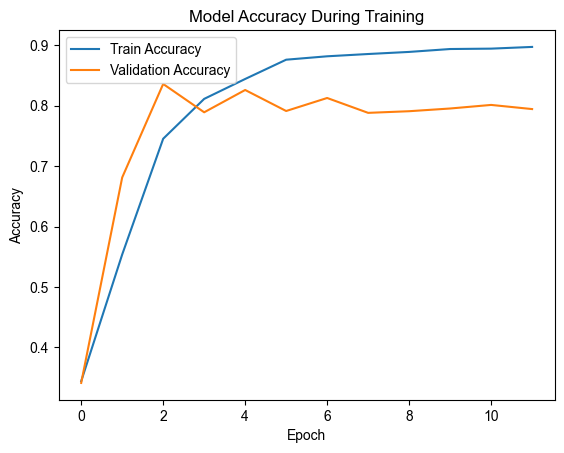

In [45]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy During Training')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 📊 Model Evaluation


In [46]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['neg', 'neu', 'pos']))

Test Accuracy: 80.44%
265/265 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step

Detailed Classification Report:
              precision    recall  f1-score   support

         neg       0.86      0.68      0.76      2097
         neu       0.72      0.99      0.83      2877
         pos       0.88      0.73      0.80      3481

    accuracy                           0.80      8455
   macro avg       0.82      0.80      0.80      8455
weighted avg       0.82      0.80      0.80      8455



## 🟦 Confusion Matrix


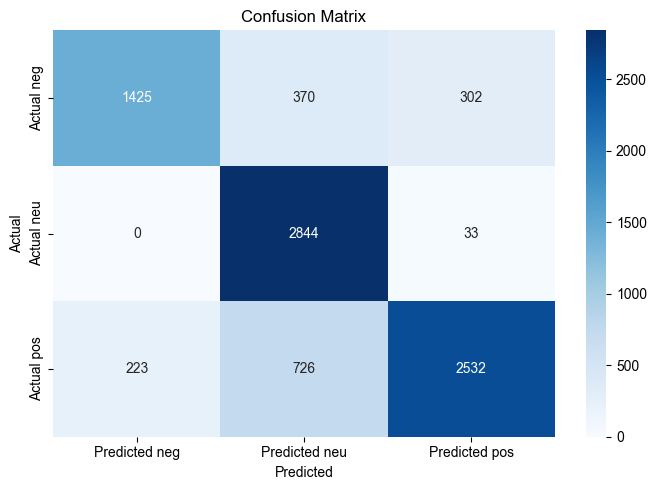

In [47]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted neg', 'Predicted neu', 'Predicted pos'],
            yticklabels=['Actual neg', 'Actual neu', 'Actual pos'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

## 🔮 Predict New Reviews


In [48]:
def predict_sentiment(texts):
    cleaned = [clean_arabic_text(t) for t in texts]
    cleaned = [remove_stopwords(t) for t in cleaned]

    seq    = tokenizer.texts_to_sequences(cleaned)
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    predictions = model.predict(padded, verbose=0)
    labels = {0: 'Negative 😞', 1: 'Neutral 😐', 2: 'Positive 😊'}

    print("\n" + "="*50)
    for text, pred in zip(texts, predictions):
        class_idx = np.argmax(pred)
        label     = labels[class_idx]
        conf      = float(pred[class_idx])
        print(f"Text       : {text}")
        print(f"Sentiment  : {label}")
        print(f"Confidence : {conf*100:.1f}%")
        print("-"*50)

my_texts = [
    "هذا المنتج رائع جداً وسريع",
    "تجربة سيئة جداً ما أنصح فيه",
    "الخدمة ممتازة وسريعة الاستجابة",
    "بطيء ومزعج ما يستحق الشراء",
    "المنتج عادي لا بأس فيه",
]
predict_sentiment(my_texts)


Text       : هذا المنتج رائع جداً وسريع
Sentiment  : Positive 😊
Confidence : 97.8%
--------------------------------------------------
Text       : تجربة سيئة جداً ما أنصح فيه
Sentiment  : Negative 😞
Confidence : 97.9%
--------------------------------------------------
Text       : الخدمة ممتازة وسريعة الاستجابة
Sentiment  : Positive 😊
Confidence : 95.6%
--------------------------------------------------
Text       : بطيء ومزعج ما يستحق الشراء
Sentiment  : Negative 😞
Confidence : 94.2%
--------------------------------------------------
Text       : المنتج عادي لا بأس فيه
Sentiment  : Neutral 😐
Confidence : 98.1%
--------------------------------------------------


## 💾 Save Model & Tokenizer


In [49]:
import pickle, os

os.makedirs('../model', exist_ok=True)

# حفظ الموديل
model.save('../model/sentiment_model.keras')

# حفظ الـ tokenizer
with open('../model/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# حفظ الـ label encoder
with open('../model/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ تم الحفظ!")

✅ تم الحفظ!
